# Importing libraries

In [ ]:
from oceanicospy.gis import ShapefileReprojector, reproject_xyz_file, XYZMerger, XYZPointPlotter, AxisAlignedRectangle, XYZRectangleMask
from oceanicospy.gis import read_xyz, write_xyz
import matplotlib.pyplot as plt
import cmocean
import pandas as pd
import numpy as np
from oceanicospy.gis import ProfileBuilder

# Inverting or removing

In [ ]:
def process_xyz_z(
    input_path: str, 
    output_path: str, 
    mode: str = "invert", 
    sep: str = r"\s+"
) -> None:
    """
    Process an .xyz file by either inverting the sign of z or 
    removing rows where z < 0, depending on the selected mode.

    Parameters
    ----------
    input_path : str
        Path to the input .xyz file.
    output_path : str
        Path to the output .xyz file.
    mode : str, optional
        Processing mode. 
        "invert" -> invert sign of z.
        "remove_negative" -> remove rows where z < 0.
    sep : str, optional
        Column separator. Default assumes whitespace.
    """
    # Read XYZ file without header (assumes columns x y z)
    df = pd.read_csv(input_path, sep=sep, header=None, names=["x", "y", "z"])

    # Select processing mode
    if mode == "invert":
        # Invert sign of z
        df["z"] = -df["z"]
    elif mode == "remove_negative":
        # Remove rows where z is negative
        df = df[df["z"] >= 0]
    else:
        raise ValueError("Invalid mode. Use 'invert' or 'remove_negative'.")

    # Save processed file maintaining xyz structure
    df.to_csv(output_path, sep=" ", index=False, header=False)
    print(f"File saved: {output_path}")


In [ ]:
# # Example usage to invert z values
# process_xyz_z(
#     input_path="input.xyz",
#     output_path="output_inverted.xyz",
#     mode="invert"
# )
# Example usage to remove negative z values
process_xyz_z(
    input_path=r'/scratchsan/medellin/lroserom/tesis/data/topobathymetry/processed/xyz/bat_sai_10m_AC_MAGNA-ON.xyz',
    output_path=r'/scratchsan/medellin/lroserom/tesis/data/topobathymetry/processed/xyz/bat_sai_filt_10m_AC_MAGNA-ON.xyz',
    mode="remove_negative"
)

File saved: /scratchsan/medellin/lroserom/tesis/data/topobathymetry/processed/xyz/bat_sai_filt_10m_AC_MAGNA-ON.xyz


# Reprojecting from .shp to .xyz files

In [ ]:
input_shp = r'/scratchsan/medellin/lroserom/testing_oceanicospy/gis/data/raw/shp/bat_sai_10m_WGS84.shp'
output_xyz = r'/scratchsan/medellin/lroserom/testing_oceanicospy/gis/data/raw/xyz/bat_sai_10m_MAGNA-ON.xyz'

reproj = ShapefileReprojector(
    input_path=input_shp,    
    z_column="Z", # column name
    source_epsg=None    # use .prj file
)

reproj.reproject_to_epsg(9377) # MAGNA-SIRGAS / Origen-Nacional
reproj.to_xyz(output_xyz)

# Reprojecting from .xyz to .xyz files

In [ ]:
input_xyz = r'/scratchsan/medellin/lroserom/testing_oceanicospy/gis/data/raw/xyz/a1.xyz'
output_xyz = r'/scratchsan/medellin/lroserom/testing_oceanicospy/gis/data/raw/xyz/topo-bat_sai_SB_9377.xyz'

reproject_xyz_file(
    input_path=input_xyz,
    output_path=output_xyz,
    source_epsg=32617,   # UTM17N
    target_epsg=9377,   # MAGNA-SIRGAS ON  
)

# Merging .xyz files

In [ ]:
# Folder containing the individual XYZ tiles
input_dir = r'/scratchsan/medellin/lroserom/tesis/data/topobathymetry/processed/xyz/to_merge'

# Output merged XYZ path
output_xyz = r'/scratchsan/medellin/lroserom/tesis/data/topobathymetry/processed/xyz/topobat_sai_merged_lidar&10m&50m_AC_MAGNA-ON.xyz'

# Manual priority: first = highest priority
manual_priority = [
    "topobat_sai_merged_lidar&10m_bothAC_MAGNA-ON.xyz",
    "bat_sai_50m_AC_MAGNA-ON.xyz",  
]

merger = XYZMerger(
    input_dir=input_dir,
    crs_epsg="EPSG:9377",          # common CRS of all tiles
    bathy_positive=True,      # Default True if bathymetry uses a positive-downward z value
    manual_priority=manual_priority,
    xy_round_decimals=6,      # xy resolution to generate coverage polygons
)

merger.run_merge(output_xyz)

Merged XYZ exported to: /scratchsan/medellin/lroserom/tesis/data/topobathymetry/processed/xyz/topobat_sai_merged_lidar&10m&50m_AC_MAGNA-ON.xyz


# Plotting .xyz

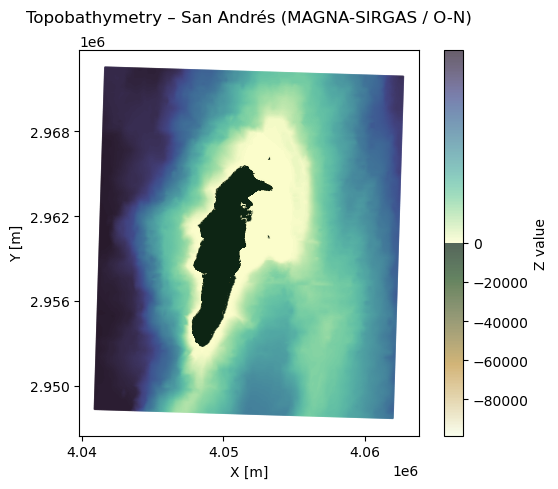

In [ ]:
xyz_path = r'/scratchsan/medellin/lroserom/tesis/data/topobathymetry/processed/xyz/topobat_sai_merged_lidar&10m&50m_AC_MAGNA-ON.xyz'
plotter = XYZPointPlotter(default_cmap=cmocean.cm.topo_r)

fig, ax = plotter.plot_xyz_points(
    source=xyz_path,
    title="Topobathymetry – San Andrés (MAGNA-SIRGAS / O-N)",
)
plt.show()

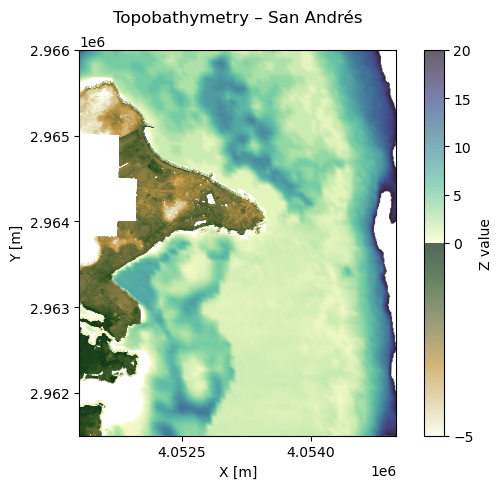

In [ ]:
xyz_path = r'/scratchsan/medellin/lroserom/tesis/data/topobathymetry/processed/xyz/topobat_sai_mergedALM_lidar&10m_bothAC_MAGNA-ON.xyz'
plotter = XYZPointPlotter(default_cmap=cmocean.cm.topo_r)

fig, ax = plotter.plot_xyz_points(
    source=xyz_path,
    cmap_range=(-5, 20), 
    xlim=(4051300, 4055000),           # optional spatial limits
    ylim=(2961500, 2966000),
    title="Topobathymetry – San Andrés",
)
plt.show()

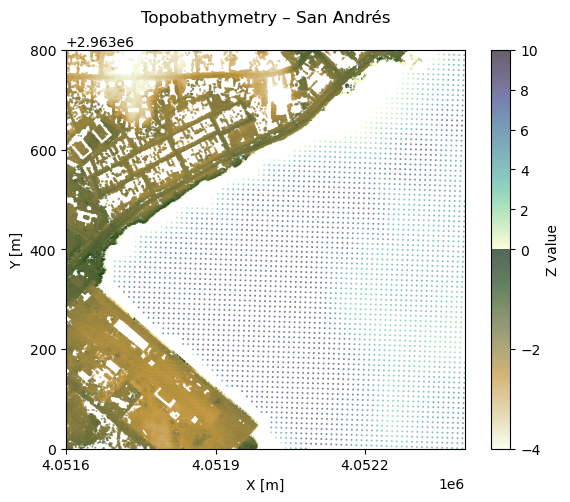

In [2]:
xyz_path = r'/scratchsan/medellin/lroserom/tesis/data/topobathymetry/processed/xyz/topobat_sai_mergedALM_lidar&10m_bothAC_MAGNA-ON.xyz'
plotter = XYZPointPlotter(default_cmap=cmocean.cm.topo_r)

fig, ax = plotter.plot_xyz_points(
    source=xyz_path,
    cmap_range=(-4, 10), 
    xlim=(4051600, 4052400),           # optional spatial limits
    ylim=(2963000, 2963800),
    title="Topobathymetry – San Andrés",
)
plt.show()

# Filtering .xyz with a rectangular mask

In [3]:
input_xyz = r'/scratchsan/medellin/lroserom/tesis/data/topobathymetry/processed/xyz/topobat_sai_mergedALM_lidar&10m_bothAC_MAGNA-ON.xyz'
output_xyz = r'/scratchsan/medellin/lroserom/tesis/data/topobathymetry/processed/xyz/topobat_sai_mergedDaniel_lidar&10m_bothAC_MAGNA-ON.xyz'

df = read_xyz(input_xyz)

rect1 = AxisAlignedRectangle(p1=(4051600, 2963000), p2=(4052400, 2963800))

masker = XYZRectangleMask([rect1])  # mode="keep" by default
df_kept = masker.filter_dataframe(df)

# Save the filtered DataFrame to a new .xyz file
write_xyz(df_kept, output_xyz)

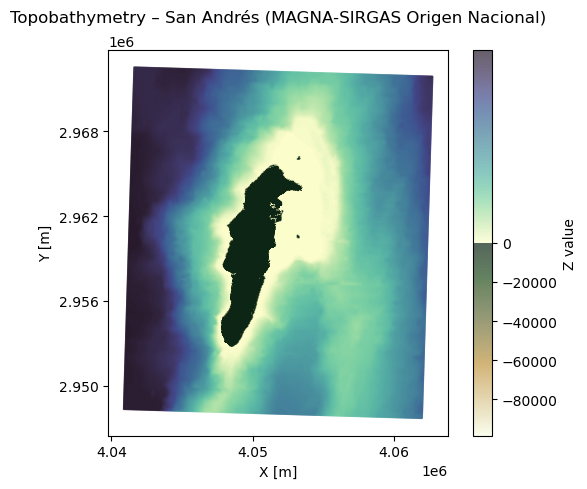

In [ ]:
xyz_path = r'/scratchsan/medellin/lroserom/testing_oceanicospy/gis/data/processed/xyz/topobat_sai_merged_lidar&50m_AC_MAGNA-ON.xyz'
plotter = XYZPointPlotter(default_cmap=cmocean.cm.topo_r)

fig, ax = plotter.plot_xyz_points(
    source=xyz_path,
    cmap_range=(0, 20),          # z-range for colors
    # xlim=(1000, 1500),           # optional spatial limits
    # ylim=(2000, 2600),
    title="Topobathymetry – San Andrés (MAGNA-SIRGAS Origen Nacional)",
    point_size=3.0,
    alpha=0.8
)
plt.show()

In [ ]:
input_xyz = r'/scratchsan/medellin/lroserom/testing_oceanicospy/gis/data/processed/xyz/topobat_sai_merged_lidar&50m_AC_MAGNA-ON.xyz'
output_xyz = r'/scratchsan/medellin/lroserom/testing_oceanicospy/gis/data/processed/xyz/topobat_sai_mergedALM_lidar&50m_AC_MAGNA-ON.xyz'

df = read_xyz(input_xyz)

rect1 = AxisAlignedRectangle(p1=(4051000, 2961500), p2=(4058000, 2967000))

masker = XYZRectangleMask([rect1])  # mode="keep" by default
df_kept = masker.filter_dataframe(df)

# Save the filtered DataFrame to a new .xyz file
write_xyz(df_kept, output_xyz)


KeyboardInterrupt: 

# Creating a profile

## 1 section

In [26]:
xyz_path = r'/scratchsan/medellin/lroserom/tesis/data/topobathymetry/processed/xyz/topobat_sai_mergedALM_lidar&10m_bothAC_MAGNA-ON.xyz'  
start = (4054866.827, 2962460.496)
end = (4051803.311, 2963542.255)
dx = 5.0
output_path = r'/scratchsan/medellin/lroserom/testing_oceanicospy/gis/data/processed/csv/profile-p1r_sai_1section.csv'

builder = ProfileBuilder(xyz_path)
df_profile = builder.generate_profile(
    path_coords=[start, end],
    dx=dx,
    output_path=output_path,
    auto_adjust_end=True
)
df_profile.head()

/homes/medellin/lroserom/oceanicospy/oceanicospy/gis/profile_builder.py:20: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(


Profile saved to: /scratchsan/medellin/lroserom/testing_oceanicospy/gis/data/processed/csv/profile-p1r_sai_1section.csv


,x,z
0,0.000000,11.923
1,4.998303,11.923
2,9.996607,11.622
3,14.994910,11.610
4,19.993213,11.289


In [23]:
def plot_profile_quick(csv_path: str):
    df = pd.read_csv(csv_path)
    s, z = df.iloc[:, 0].values, -df.iloc[:, 1].values  # assumes first two cols are x and z

    ds = np.diff(s)
    change_idx = np.where(np.abs(np.diff(ds)) > 1e-3)[0] + 1
    change_idx = np.unique(np.concatenate(([0], change_idx, [len(s) - 1])))
    # band_colors = ["#F5F0E6", "#EFE7D6"]

    fig, ax = plt.subplots(figsize=(6.5, 3.5))
    # if len(change_idx) > 2:
    #     for i in range(len(change_idx) - 1):
    #         ax.axvspan(s[change_idx[i]], s[change_idx[i + 1]], color=band_colors[i % 2], alpha=0.6, zorder=0)

    ax.fill_between(s, z, z.min() - 1.0, color="#D2B48C", alpha=0.8, zorder=1)
    ax.plot(s, z, "-o", color="black", linewidth=0.3, markersize=1, zorder=2)
    ax.set_xlabel("x [m]")
    ax.set_ylabel("z [m]")
    ax.set_xlim(s.min(), s.max())
    #ax.set_xlim(3000, s.max())
    ax.set_ylim(z.min() - 1, z.max() + 0.5)
    ax.grid(True, linestyle="--", linewidth=0.4, alpha=0.6)
    plt.tight_layout()
    plt.show()

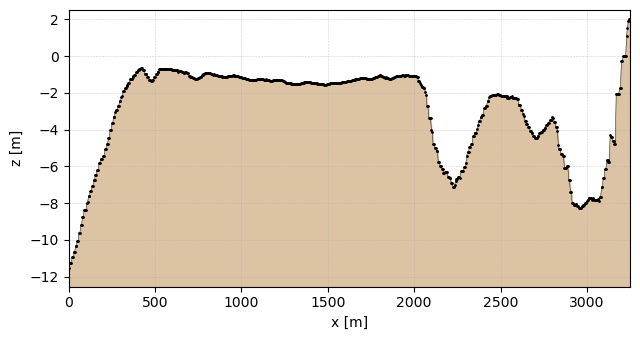

In [24]:
plot_profile_quick(r'/scratchsan/medellin/lroserom/testing_oceanicospy/gis/data/processed/csv/profile-p1l_sai_1section.csv')

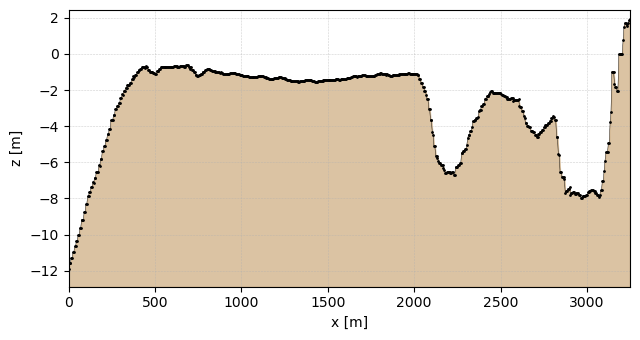

In [25]:
plot_profile_quick(r'/scratchsan/medellin/lroserom/testing_oceanicospy/gis/data/processed/csv/profile-p1_sai_1section.csv')

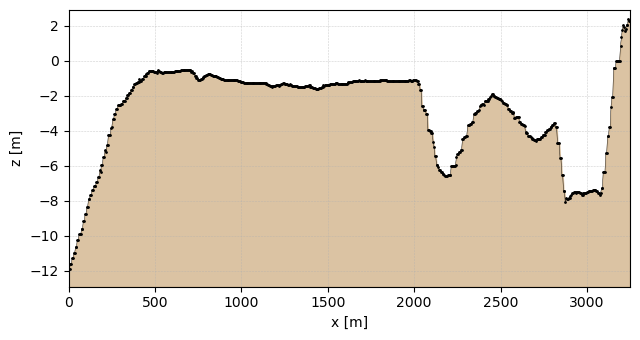

In [27]:
plot_profile_quick(r'/scratchsan/medellin/lroserom/testing_oceanicospy/gis/data/processed/csv/profile-p1r_sai_1section.csv')

## > 1 sección

In [29]:
xyz_path = xyz_path = r'/scratchsan/medellin/lroserom/tesis/data/topobathymetry/processed/xyz/topobat_sai_mergedALM_lidar&10m_bothAC_MAGNA-ON.xyz'  
path_coords = [
    (4054674.715, 2962946.761),
    (4052826.612, 2963085.702),
    (4051815.053, 2963534.973)
]
dx = 5.0
output_path = r'/scratchsan/medellin/lroserom/testing_oceanicospy/gis/data/processed/csv/profile-p2_sai_2sections.csv'

builder = ProfileBuilder(xyz_path)
df_profile = builder.generate_profile(
    path_coords=path_coords,
    dx=dx,
    output_path=output_path,
    auto_adjust_end=True
)


/homes/medellin/lroserom/oceanicospy/oceanicospy/gis/profile_builder.py:20: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(


Profile saved to: /scratchsan/medellin/lroserom/testing_oceanicospy/gis/data/processed/csv/profile-p2_sai_2sections.csv


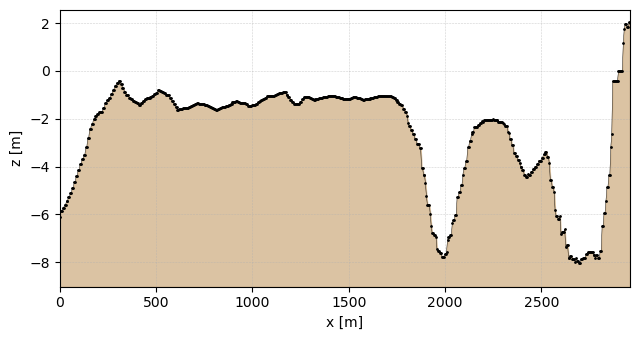

In [31]:
plot_profile_quick(r'/scratchsan/medellin/lroserom/testing_oceanicospy/gis/data/processed/csv/profile-p2_sai_2sections.csv')